# Lead Conversion Prediction Engine

This notebook contains the exploratory data analysis (EDA) and the modelling experiments.

**Part A — EDA** (numbered `STEP` cells, summarised in section 15): raw-data quality (duplicates,
invalid values, unique values), dataset structure, data types, missing values, target distribution, categorical and numerical feature relationships, correlations and outliers.

**Part B — Modelling** (sections 16–23): train/test split, leakage review, model comparison,
threshold selection, final test evaluation, feature importance and a prediction check.

The modelling code lives in `src/train.py` and is imported here, so the notebook and the
training script always run exactly the same pipeline. The notebook does **not** overwrite the
saved model; run `python src/train.py` to (re)create `models/lead_conversion_pipeline.joblib`.

Run with **Kernel → Restart & Run All** from the `notebooks/` folder or the project root.

---
# Part A — Exploratory Data Analysis

## 1. Setup and Paths

Imports, plotting style, and paths relative to the project root (works whether Jupyter starts in the project root or in `notebooks/`).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Project root
BASE_DIR = Path.cwd()

# If Jupyter starts inside the notebooks folder,
# move one level up to the project root.
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# Work from the project root so all paths below are relative and portable.
import os
os.chdir(BASE_DIR)

DATA_FILE = Path("data") / "processed" / "leads_validated.csv"
FIGURES_DIR = Path("reports") / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plotting style
sns.set_theme(style="whitegrid")

print(f"Dataset: {DATA_FILE}")
print(f"Figures: {FIGURES_DIR}")

Dataset: data/processed/leads_validated.csv
Figures: reports/figures


## 2. Load the Validated Dataset

`data/processed/leads_validated.csv` is produced by `src/validate_data.py` (duplicates removed, invalid values set to missing).

In [2]:
df = pd.read_csv(DATA_FILE)

print(f"Shape: {df.shape}")

display(df.head())

Shape: (6000, 16)


,lead_id,lead_source,industry,location,company_size,lead_age_days,interactions,followups,response_time_hours,quotation_sent,quotation_value,website_visits,previous_customer,demo_attended,salesperson_experience,converted
0,100001,Cold Call,Healthcare,Pune,Medium,45.0,3,2,13.85,0,0.00,0,0,0,2,0
1,100002,Email Campaign,Technology,Mumbai,Small,44.0,4,2,24.76,0,0.00,4,0,0,6,0
2,100003,Cold Call,Retail,Delhi,Medium,119.0,1,0,13.49,0,0.00,2,0,0,11,0
3,100004,Social Media,Technology,Hyderabad,Large,88.0,5,1,12.54,1,199137.61,4,0,0,7,0
4,100005,Website,Technology,Pune,Medium,104.0,6,1,19.18,0,0.00,7,0,0,3,0


## 3. Data Types and Structure

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   lead_id                 6000 non-null   int64  
 1   lead_source             5940 non-null   str    
 2   industry                5940 non-null   str    
 3   location                6000 non-null   str    
 4   company_size            5940 non-null   str    
 5   lead_age_days           5990 non-null   float64
 6   interactions            6000 non-null   int64  
 7   followups               6000 non-null   int64  
 8   response_time_hours     5930 non-null   float64
 9   quotation_sent          6000 non-null   int64  
 10  quotation_value         5940 non-null   float64
 11  website_visits          6000 non-null   int64  
 12  previous_customer       6000 non-null   int64  
 13  demo_attended           6000 non-null   int64  
 14  salesperson_experience  6000 non-null   int64  
 15

## 4. Summary Statistics and Unique Values

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
lead_id,6000.0,NaN,NaN,NaN,103000.5,1732.195139,100001.0,101500.75,103000.5,104500.25,106000.0
lead_source,5940,6,Website,1533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,5940,6,Technology,1424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,6000,7,Pune,893,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,5940,4,Medium,2030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lead_age_days,5990.0,NaN,NaN,NaN,60.251085,34.505491,1.0,31.0,60.0,90.0,120.0
interactions,6000.0,NaN,NaN,NaN,4.935167,2.370844,0.0,3.0,5.0,6.0,14.0
followups,6000.0,NaN,NaN,NaN,2.053,1.565333,0.0,1.0,2.0,3.0,11.0
response_time_hours,5930.0,NaN,NaN,NaN,23.492472,19.433998,1.11,10.81,17.92,29.3275,168.0
quotation_sent,6000.0,NaN,NaN,NaN,0.425333,0.494435,0.0,0.0,0.0,1.0,1.0


## 5. Missing Values

In [5]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary)

,missing_count,missing_percentage
response_time_hours,70,1.17
lead_source,60,1.00
industry,60,1.00
company_size,60,1.00
quotation_value,60,1.00
lead_age_days,10,0.17


## 6. Missing-Value Chart

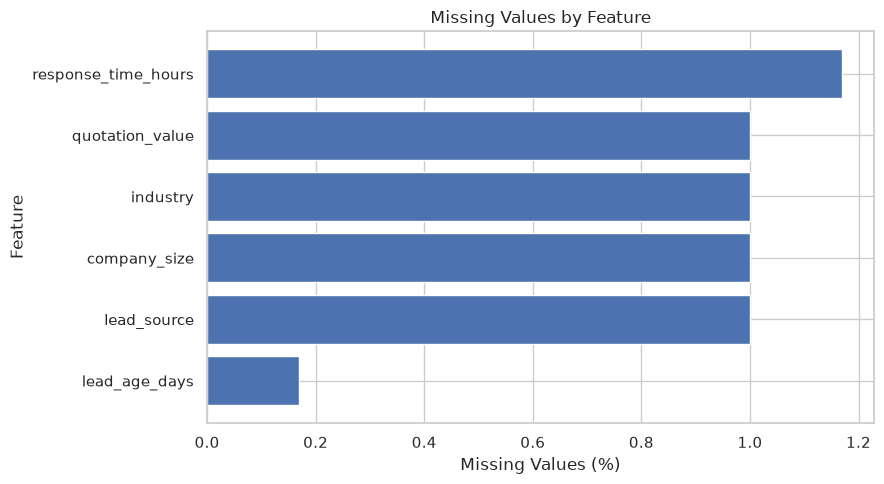

Saved figure: reports/figures/missing_values.png


In [6]:
plt.figure(figsize=(9, 5))

missing_plot = missing_summary.sort_values(
    "missing_percentage",
    ascending=True
)

plt.barh(
    missing_plot.index,
    missing_plot["missing_percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.tight_layout()

missing_figure = FIGURES_DIR / "missing_values.png"
plt.savefig(missing_figure, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {missing_figure}")

## 7. Target Distribution

Is the dataset balanced? This decides how much weight accuracy can carry.

In [7]:
target_counts = df["converted"].value_counts().sort_index()
target_percent = (
    df["converted"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent
})

display(target_summary)

,count,percentage
converted,,
0,3373,56.22
1,2627,43.78


## 8. Target Distribution Chart

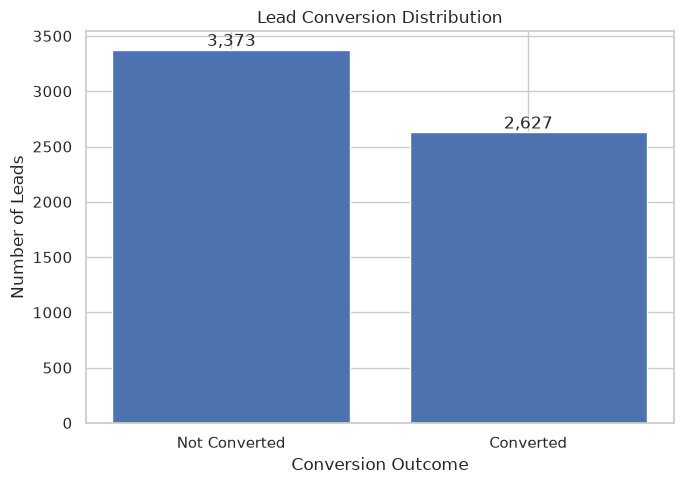

Saved figure: reports/figures/target_distribution.png


In [8]:
plt.figure(figsize=(7, 5))

labels = ["Not Converted", "Converted"]
values = target_counts.values

bars = plt.bar(labels, values)

plt.ylabel("Number of Leads")
plt.xlabel("Conversion Outcome")
plt.title("Lead Conversion Distribution")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

target_figure = FIGURES_DIR / "target_distribution.png"
plt.savefig(target_figure, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved figure: {target_figure}")

## 9. Categorical Feature Distributions

LEAD_SOURCE DISTRIBUTION


,count
lead_source,
Website,1533
Referral,1050
Cold Call,956
Email Campaign,903
Social Media,818
Partner,680
NaN,60


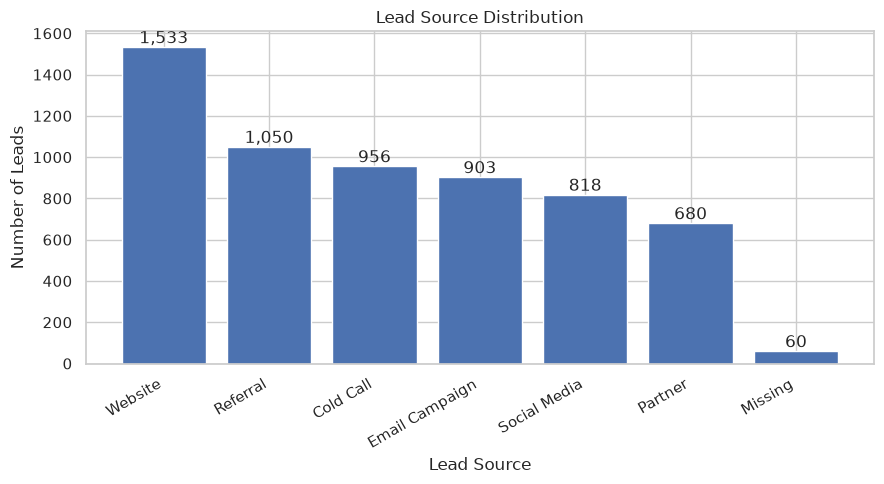

Saved figure: reports/figures/lead_source_distribution.png
INDUSTRY DISTRIBUTION


,count
industry,
Technology,1424
Retail,1078
Finance,1000
Healthcare,878
Manufacturing,865
Education,695
NaN,60


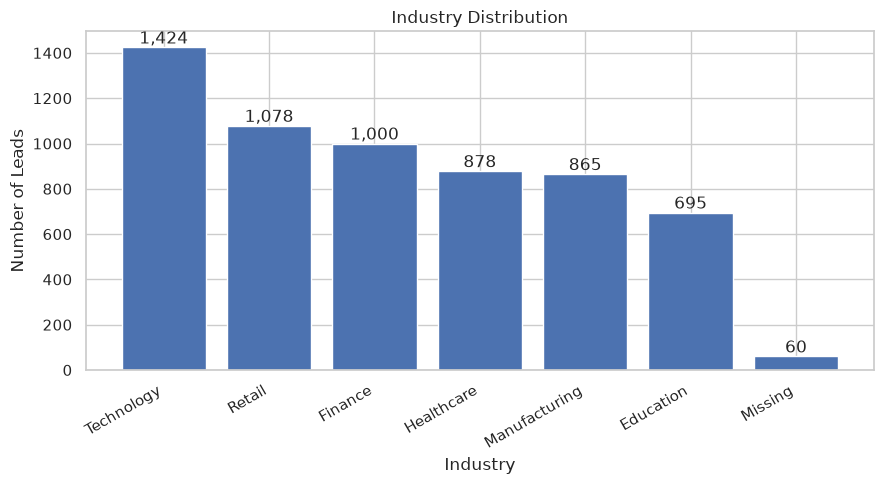

Saved figure: reports/figures/industry_distribution.png
LOCATION DISTRIBUTION


,count
location,
Pune,893
Bengaluru,875
Delhi,872
Hyderabad,870
Mumbai,836
Chennai,828
Kolkata,826


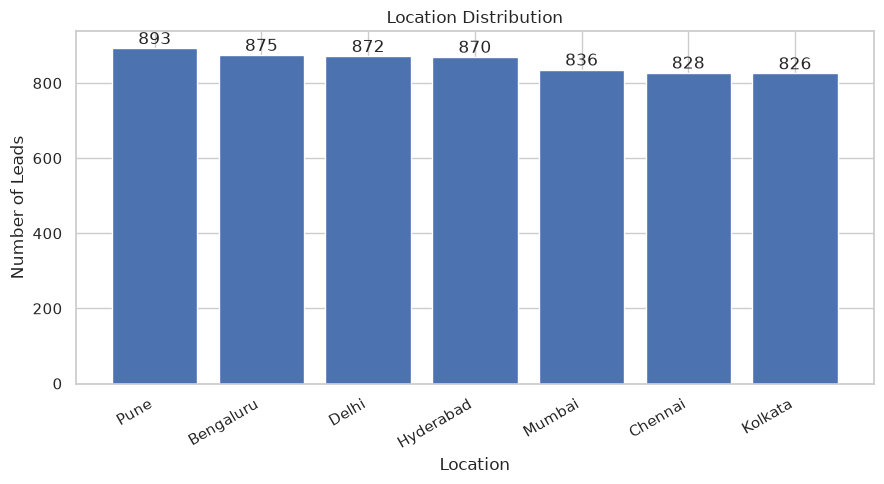

Saved figure: reports/figures/location_distribution.png
COMPANY_SIZE DISTRIBUTION


,count
company_size,
Medium,2030
Small,1761
Large,1515
Enterprise,634
NaN,60


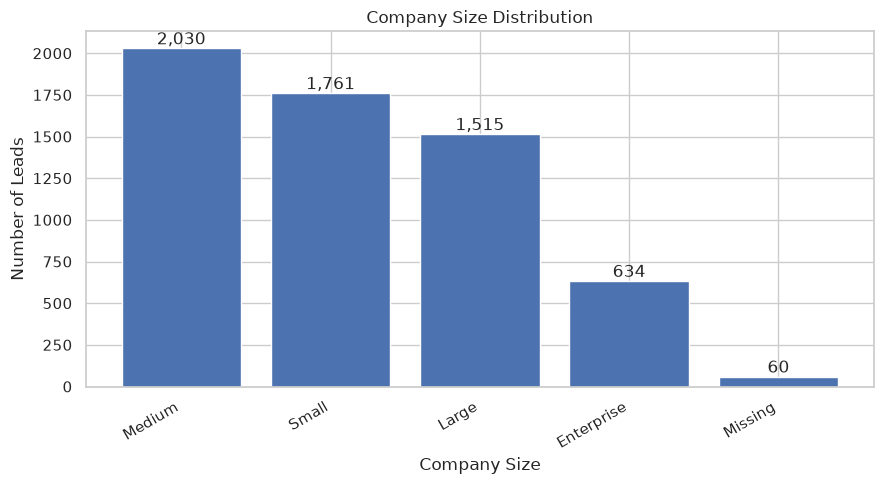

Saved figure: reports/figures/company_size_distribution.png


In [9]:
categorical_features = [
    "lead_source",
    "industry",
    "location",
    "company_size"
]

for feature in categorical_features:
    print("=" * 70)
    print(f"{feature.upper()} DISTRIBUTION")
    print("=" * 70)

    display(
        df[feature]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    plt.figure(figsize=(9, 5))

    counts = df[feature].fillna("Missing").value_counts()

    bars = plt.bar(
        counts.index.astype(str),
        counts.values
    )

    plt.title(f"{feature.replace('_', ' ').title()} Distribution")
    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Number of Leads")
    plt.xticks(rotation=30, ha="right")

    for bar, value in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    figure_path = FIGURES_DIR / f"{feature}_distribution.png"
    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved figure: {figure_path}")

## 10. Numerical Feature Summary and Distributions

In [10]:
numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_value",
    "website_visits",
    "salesperson_experience"
]

display(df[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
lead_age_days,5990.0,60.251085,34.505491,1.00,31.00,60.00,90.0000,120.00
interactions,6000.0,4.935167,2.370844,0.00,3.00,5.00,6.0000,14.00
followups,6000.0,2.053000,1.565333,0.00,1.00,2.00,3.0000,11.00
response_time_hours,5930.0,23.492472,19.433998,1.11,10.81,17.92,29.3275,168.00
quotation_value,5940.0,45683.298811,82792.651737,0.00,0.00,0.00,65338.0250,951675.15
website_visits,6000.0,3.723333,2.152803,0.00,2.00,3.00,5.0000,14.00
salesperson_experience,6000.0,7.999833,4.322185,1.00,4.00,8.00,12.0000,15.00


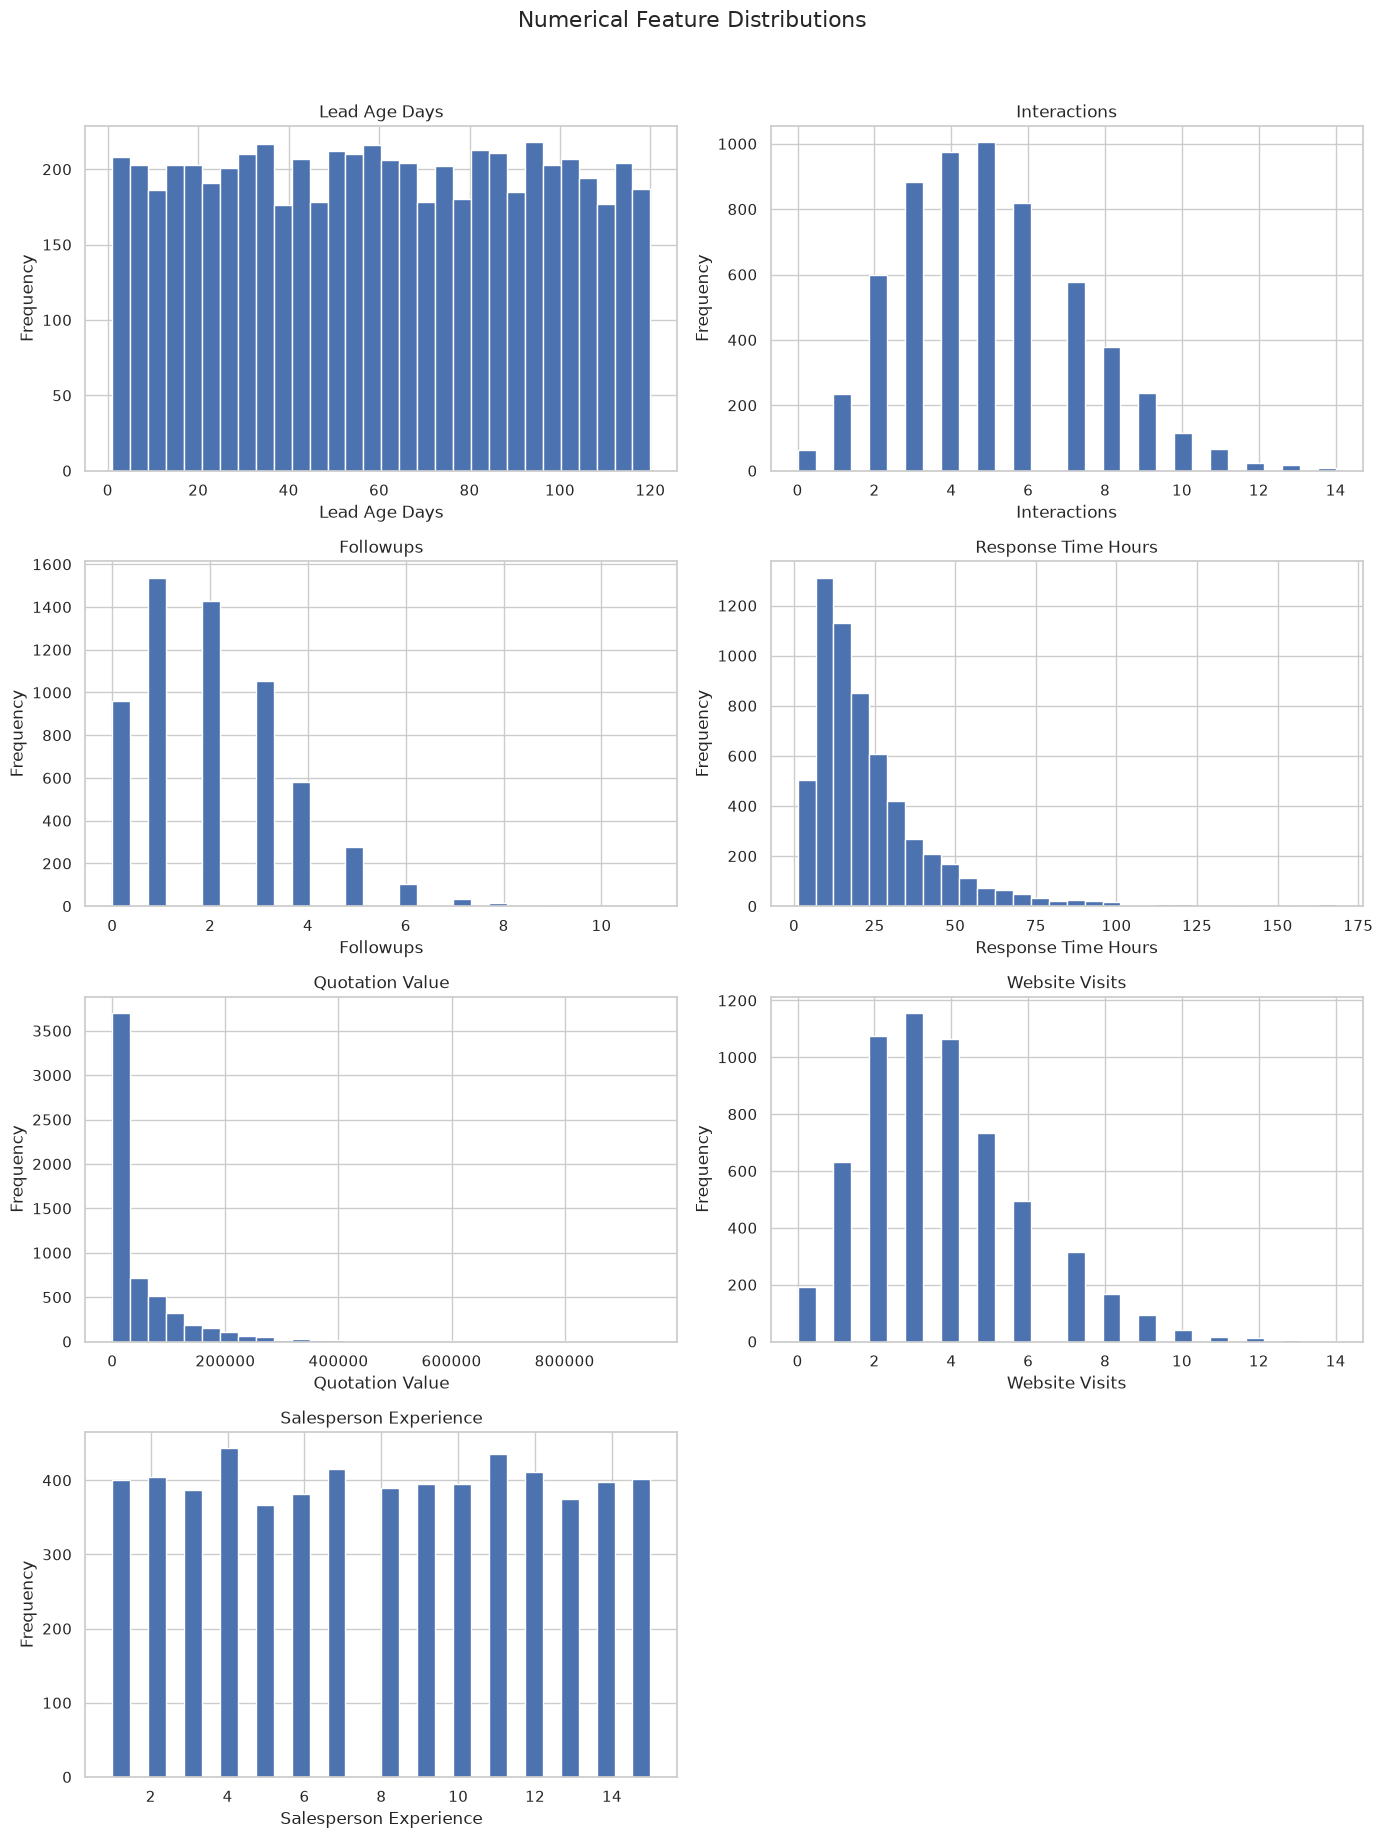

Saved figure: reports/figures/numerical_feature_distributions.png


In [11]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].hist(
        df[feature].dropna(),
        bins=30
    )
    
    axes[i].set_title(
        feature.replace("_", " ").title()
    )
    axes[i].set_xlabel(
        feature.replace("_", " ").title()
    )
    axes[i].set_ylabel("Frequency")

# Hide the unused eighth subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

numerical_distribution_figure = (
    FIGURES_DIR / "numerical_feature_distributions.png"
)

plt.savefig(
    numerical_distribution_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {numerical_distribution_figure}"
)

## 11. Numerical Outlier Inspection

Extreme values are inspected, not deleted: large response times and quotation values are plausible business observations.

/tmp/ipykernel_5009/3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
/tmp/ipykernel_5009/3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
/tmp/ipykernel_5009/3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
/tmp/ipykernel_5009/3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[i].boxplot(
/tmp/ipykernel_5009/3356572377.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Us

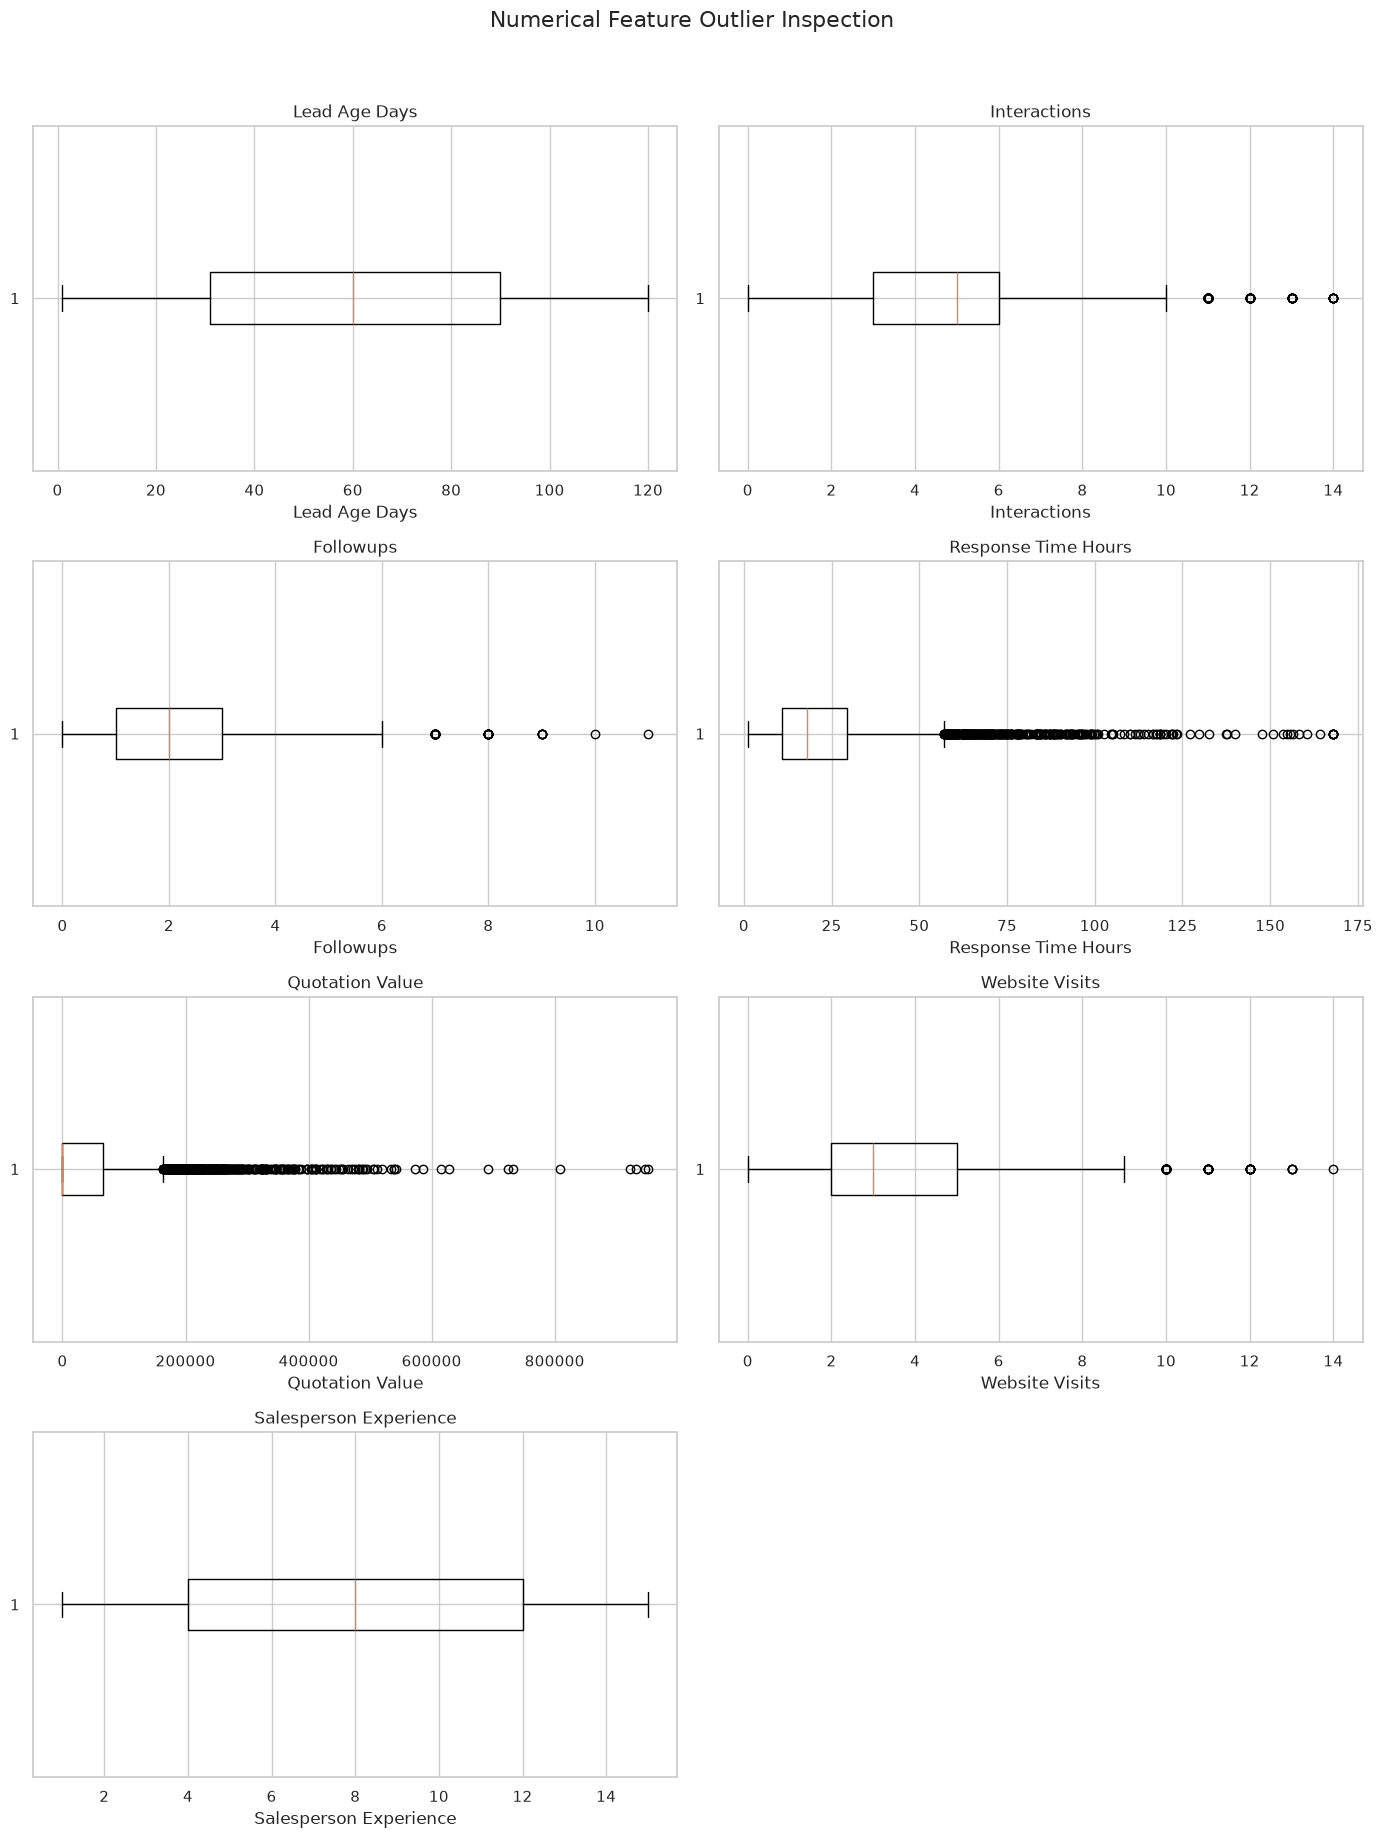

Saved figure: reports/figures/numerical_outlier_inspection.png


In [12]:
# STEP 11 — Numerical Outlier Inspection

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 18)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    axes[i].boxplot(
        df[feature].dropna(),
        vert=False
    )
    
    axes[i].set_title(
        feature.replace("_", " ").title()
    )
    axes[i].set_xlabel(
        feature.replace("_", " ").title()
    )

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Feature Outlier Inspection",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

outlier_figure = (
    FIGURES_DIR / "numerical_outlier_inspection.png"
)

plt.savefig(
    outlier_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {outlier_figure}"
)

## 12. Numerical Features vs Conversion

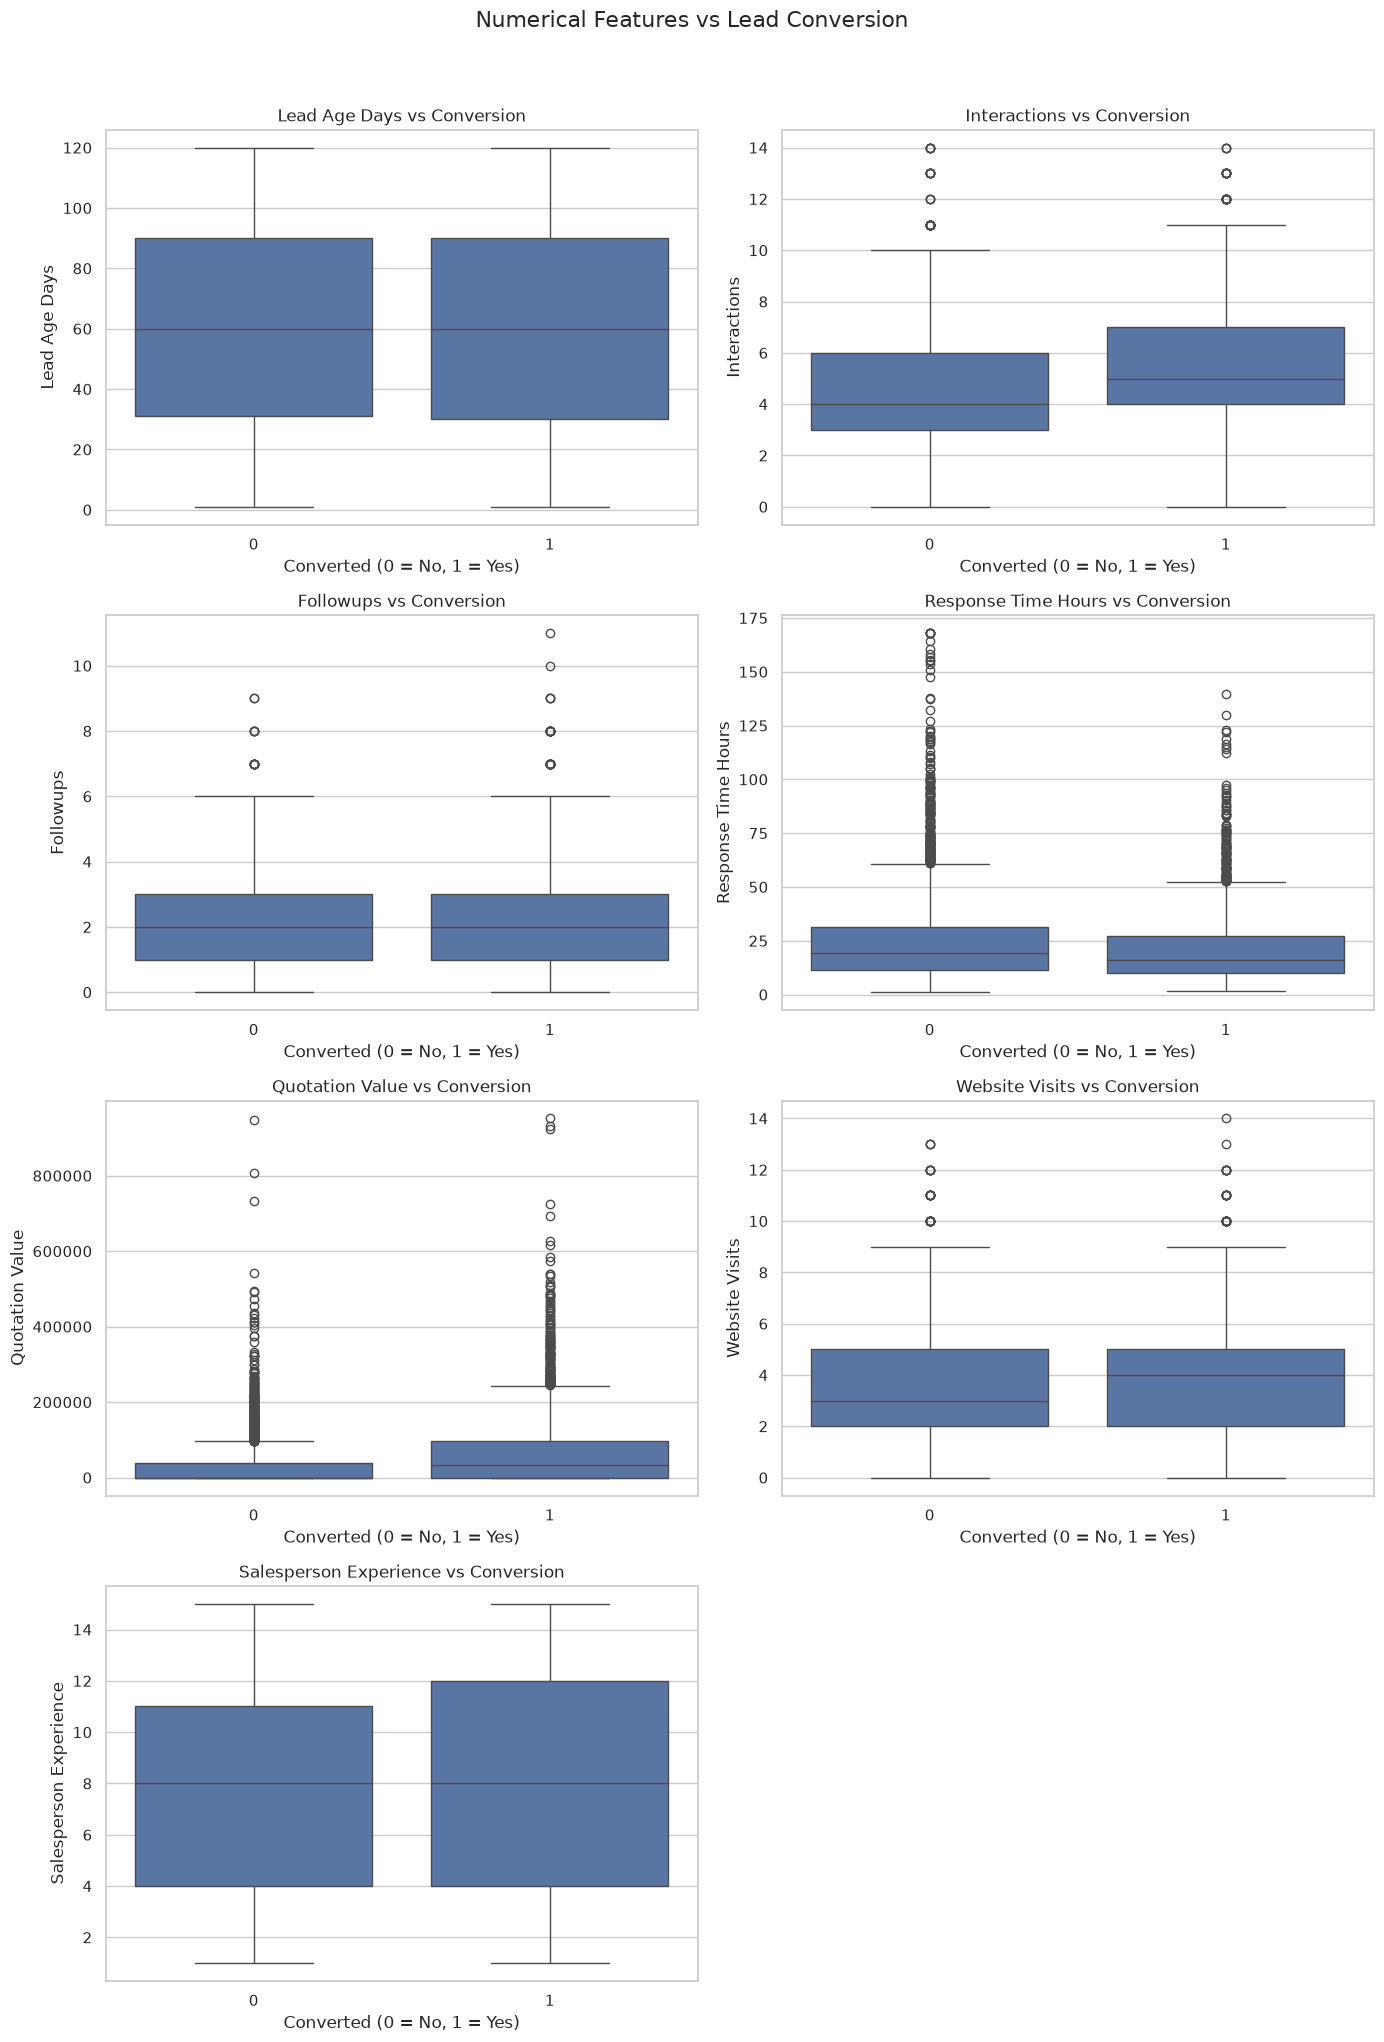

Saved figure: reports/figures/numerical_features_vs_conversion.png


In [13]:
# STEP 12 — Numerical Features vs Conversion

numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_value",
    "website_visits",
    "salesperson_experience"
]

fig, axes = plt.subplots(
    4, 2,
    figsize=(14, 20)
)

axes = axes.flatten()

for i, feature in enumerate(numerical_features):

    sns.boxplot(
        data=df,
        x="converted",
        y=feature,
        ax=axes[i]
    )

    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} vs Conversion"
    )

    axes[i].set_xlabel(
        "Converted (0 = No, 1 = Yes)"
    )

    axes[i].set_ylabel(
        feature.replace("_", " ").title()
    )

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle(
    "Numerical Features vs Lead Conversion",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

feature_target_figure = (
    FIGURES_DIR / "numerical_features_vs_conversion.png"
)

plt.savefig(
    feature_target_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {feature_target_figure}"
)

## 13. Categorical Features vs Conversion

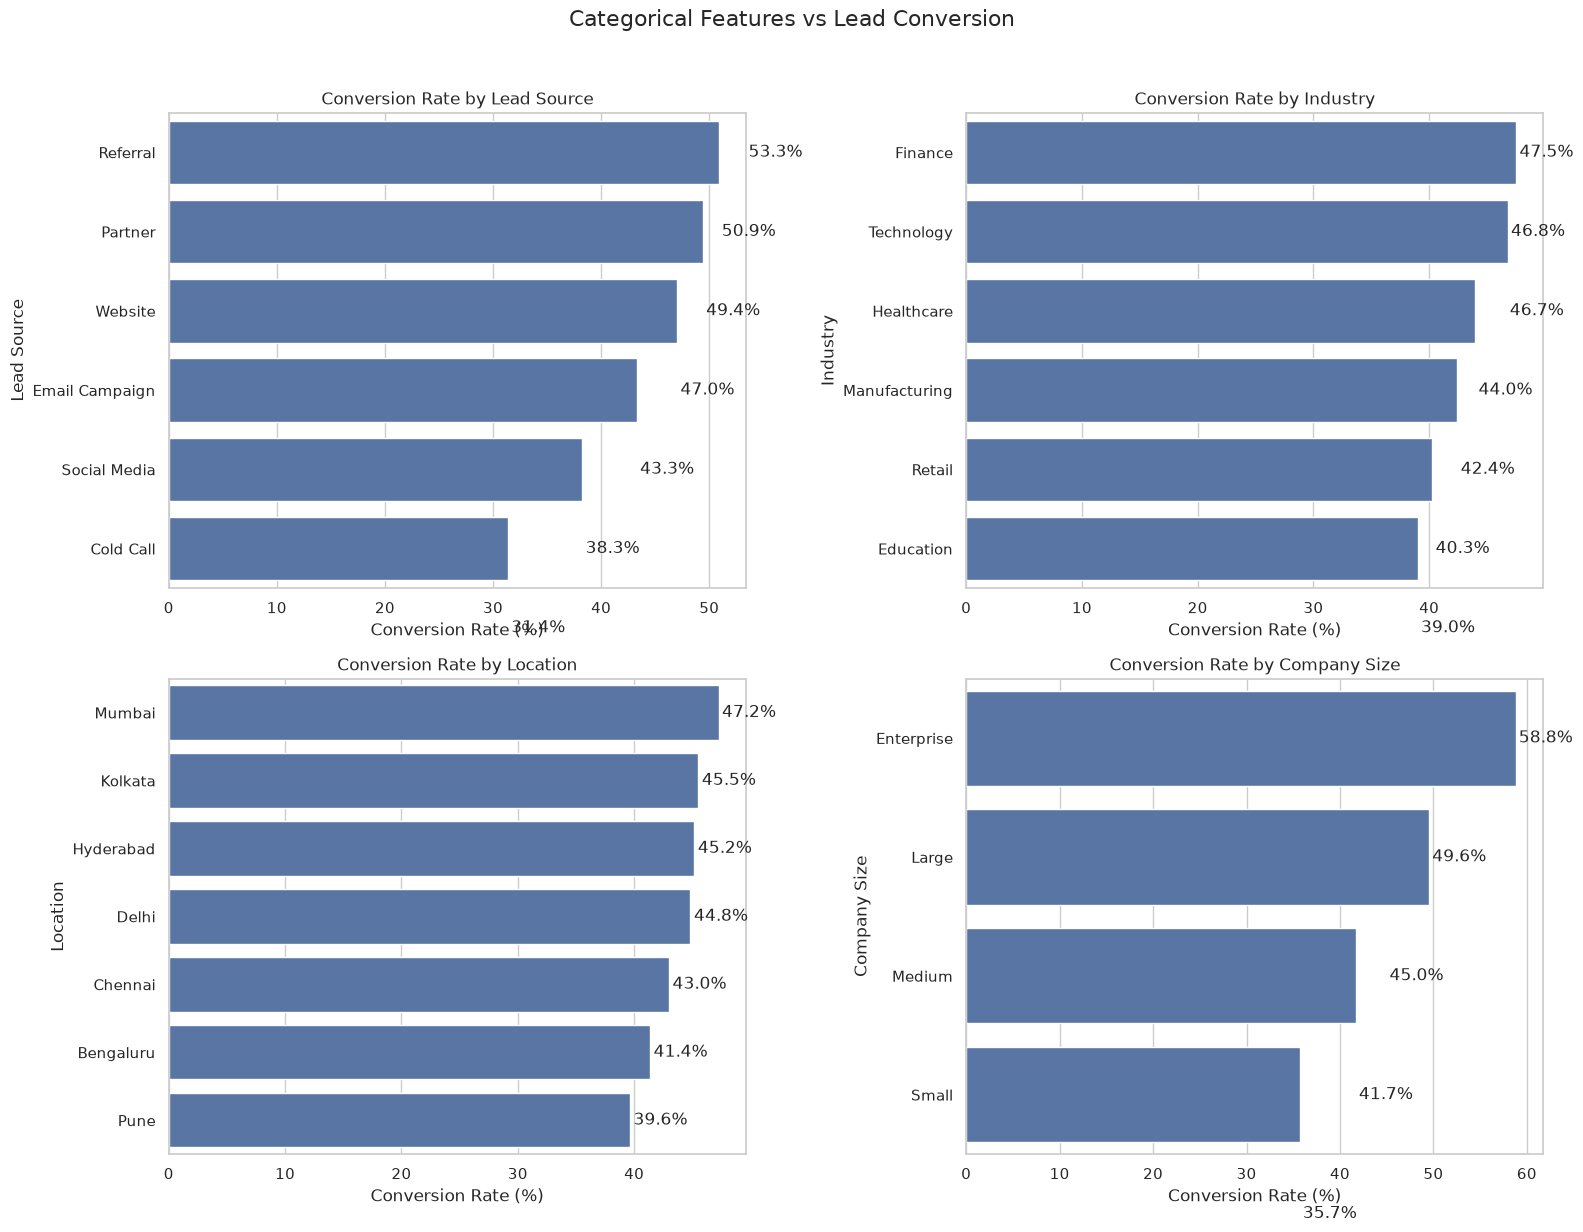

Saved figure: reports/figures/categorical_features_vs_conversion.png


In [14]:
# STEP 13 — Categorical Features vs Conversion

categorical_features = [
    "lead_source",
    "industry",
    "location",
    "company_size"
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    conversion_rates = (
        df.groupby(feature, dropna=False)["converted"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    conversion_rates.index = conversion_rates.index.astype(str)

    sns.barplot(
        x=conversion_rates.values,
        y=conversion_rates.index,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Conversion Rate by {feature.replace('_', ' ').title()}"
    )

    axes[i].set_xlabel("Conversion Rate (%)")
    axes[i].set_ylabel(
        feature.replace("_", " ").title()
    )

    for j, value in enumerate(conversion_rates.values):
        axes[i].text(
            value + 0.3,
            j,
            f"{value:.1f}%",
            va="center"
        )

plt.suptitle(
    "Categorical Features vs Lead Conversion",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

categorical_target_figure = (
    FIGURES_DIR / "categorical_features_vs_conversion.png"
)

plt.savefig(
    categorical_target_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {categorical_target_figure}"
)

## 14. Numerical Correlation Analysis

,spearman_correlation_with_converted
quotation_value,0.263933
demo_attended,0.262768
quotation_sent,0.245741
interactions,0.199876
followups,0.155417
previous_customer,0.140897
website_visits,0.091891
salesperson_experience,0.051653
lead_age_days,-0.002873
response_time_hours,-0.112975


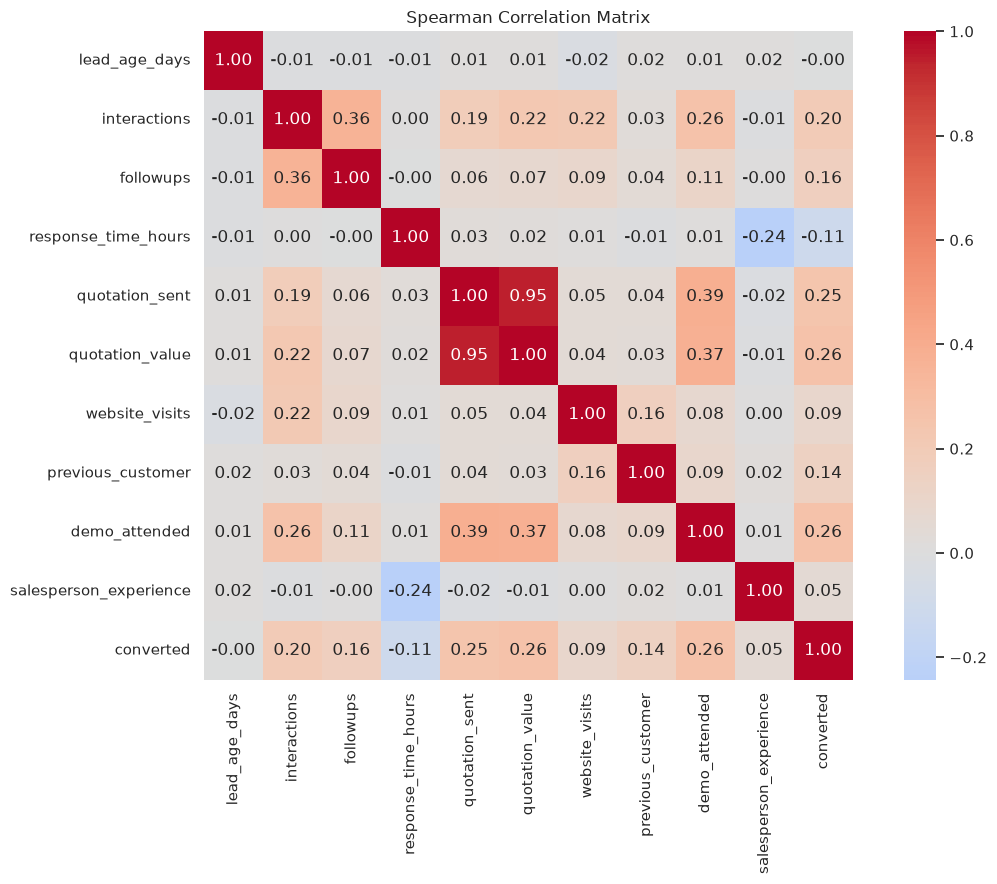

Saved figure: reports/figures/correlation_matrix.png


In [15]:
# STEP 14 — Numerical Correlation Analysis

numerical_features = [
    "lead_age_days",
    "interactions",
    "followups",
    "response_time_hours",
    "quotation_sent",
    "quotation_value",
    "website_visits",
    "previous_customer",
    "demo_attended",
    "salesperson_experience",
    "converted"
]

correlation_matrix = df[numerical_features].corr(
    method="spearman"
)

# Correlation of each numerical feature with the target
target_correlation = (
    correlation_matrix["converted"]
    .drop("converted")
    .sort_values(ascending=False)
)

display(
    target_correlation.to_frame(
        name="spearman_correlation_with_converted"
    )
)

# Plot correlation heatmap
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Spearman Correlation Matrix")

plt.tight_layout()

correlation_figure = (
    FIGURES_DIR / "correlation_matrix.png"
)

plt.savefig(
    correlation_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved figure: {correlation_figure}"
)

### Raw-Data Quality Checks

The cells above use the cleaned file. This check runs on the **raw** file produced by
`src/generate_data.py`, to show the problems that `src/validate_data.py` found and fixed.

In [16]:
raw = pd.read_csv(Path("data") / "raw" / "leads_raw.csv")

print(f"Raw shape: {raw.shape}   Cleaned shape: {df.shape}")
print(f"Exact duplicate rows in raw data: {raw.duplicated().sum()}")

numeric_columns = raw.select_dtypes("number").columns.drop(["lead_id", "converted"])
invalid = (raw[numeric_columns] < 0).sum()
print("\nNegative (invalid) values in raw data:")
display(invalid[invalid > 0].to_frame("negative_count"))

print("Unique values per column:")
display(raw.nunique().to_frame("unique_values").T)

sent_without_value = ((raw["quotation_sent"] == 1) & raw["quotation_value"].isna()).sum()
value_without_sent = ((raw["quotation_sent"] == 0) & (raw["quotation_value"] > 0)).sum()
print(f"Quotation sent but value missing : {sent_without_value}")
print(f"Quotation value but not sent     : {value_without_sent}")
print("\nCleaned data — duplicates:", df.duplicated().sum(),
      "| negative values:", int((df[numeric_columns] < 0).sum().sum()))

Raw shape: (6020, 16)   Cleaned shape: (6000, 16)
Exact duplicate rows in raw data: 20

Negative (invalid) values in raw data:


,negative_count
lead_age_days,10
response_time_hours,10


Unique values per column:


,lead_id,lead_source,industry,location,company_size,lead_age_days,interactions,followups,response_time_hours,quotation_sent,quotation_value,website_visits,previous_customer,demo_attended,salesperson_experience,converted
unique_values,6000,6,6,7,4,121,15,12,3348,2,2532,15,2,2,15,2


Quotation sent but value missing : 21
Quotation value but not sent     : 0

Cleaned data — duplicates: 0 | negative values: 0


### Conversion vs Yes/No Features

Direct comparison of conversion rates for the three binary sales-activity features.

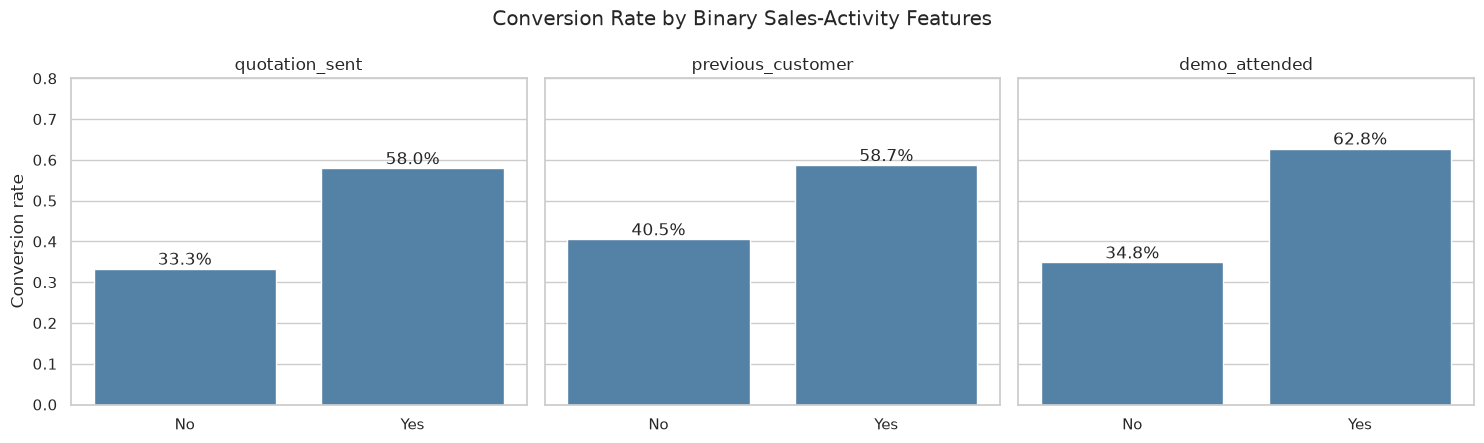

Saved figure: reports/figures/binary_features_vs_conversion.png


,quotation_sent,previous_customer,demo_attended
0,0.333,0.405,0.348
1,0.580,0.587,0.628


In [17]:
binary_features = ["quotation_sent", "previous_customer", "demo_attended"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, feature in zip(axes, binary_features):
    rates = df.groupby(feature)["converted"].mean().rename({0: "No", 1: "Yes"})
    sns.barplot(x=rates.index, y=rates.values, ax=ax, color="steelblue")
    for i, value in enumerate(rates.values):
        ax.text(i, value + 0.01, f"{value:.1%}", ha="center")
    ax.set(title=feature, xlabel="", ylabel="Conversion rate" if feature == binary_features[0] else "")
ax.set_ylim(0, 0.8)
plt.suptitle("Conversion Rate by Binary Sales-Activity Features")
plt.tight_layout()

binary_figure = FIGURES_DIR / "binary_features_vs_conversion.png"
plt.savefig(binary_figure, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {binary_figure}")

display(pd.DataFrame({f: df.groupby(f)["converted"].mean().round(3) for f in binary_features}))

## 15. Exploratory Data Analysis — Key Findings

### Dataset Overview
- The validated dataset contains 6,000 leads and 16 columns.
- The target variable is `converted`.
- The dataset contains both numerical and categorical predictors.
- Missing values are present but remain low overall, with the highest missingness in `response_time_hours` at approximately 1.17% (including invalid values set to missing).

### Target Distribution
- 3,373 leads were not converted.
- 2,627 leads were converted.
- The conversion rate is approximately 43.8%.
- The target is moderately balanced and does not require aggressive class-balancing assumptions at this stage.

### Numerical Feature Observations
- `lead_age_days` is distributed across approximately 1–120 days.
- `interactions` and `followups` are concentrated around lower integer values.
- `response_time_hours` is right-skewed and contains substantial high-value outliers.
- `quotation_value` is strongly right-skewed with many zero values and several high-value observations.
- `website_visits` is concentrated around a small number of visits.
- `salesperson_experience` spans approximately 1–15 years.

### Categorical Feature Observations
- Conversion rates vary across lead sources, industries, locations, and company sizes.
- Lead source shows noticeable variation in observed conversion rates.
- Company size also shows variation in observed conversion rates.
- These relationships will be encoded and evaluated by the machine-learning pipeline rather than manually converted into rules.

### Correlation Findings
- `quotation_value` and `quotation_sent` show the strongest positive numerical relationships with conversion.
- `previous_customer` and `demo_attended` also show positive relationships with conversion.
- `response_time_hours` shows a modest negative relationship with conversion.
- Other numerical variables show relatively weak individual monotonic relationships with the target.
- `quotation_sent` and `quotation_value` are highly correlated with each other, with a Spearman correlation of approximately 0.95.
- The funnel features are related to each other, as in a real sales process: interactions correlate with follow-ups (Spearman ≈ 0.36) and demo attendance, and a demo makes a quotation much more likely (71% vs 29%).
- Correlation alone will not be used to eliminate features because machine-learning models can capture nonlinear and combined effects.

### EDA Conclusion
The dataset is suitable for supervised binary classification after preprocessing.

The next stage is to build a reproducible machine-learning preprocessing pipeline that:
1. separates features and target,
2. handles missing values,
3. encodes categorical variables,
4. prepares numerical features,
5. performs a stratified train/test split,
6. prevents data leakage,
7. and prepares the data for baseline model training.

---
# Part B — Modelling

## 16. Features, Target and Stratified Train/Test Split

- `lead_id` is dropped: it is an identifier and carries no predictive meaning.
- The split is 80/20 and **stratified** on `converted`, so both sets keep the 43.8% conversion rate.
- The test set is set aside and used **only once**, for the final evaluation. Model selection,
  tuning and threshold selection use the training set only (cross-validation).

In [18]:
import sys
sys.path.insert(0, str(Path.cwd()))

from IPython.display import Image, display

import src.train as train

X, y = train.load_data(DATA_FILE)
X_train, X_test, y_train, y_test = train.split_data(X, y)

print(f"Features used: {len(train.FEATURES)}  (lead_id excluded)")
print(f"Train: {X_train.shape}   Test: {X_test.shape}")

split_summary = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True),
}).sort_index()
split_summary.index = ["Not Converted (0)", "Converted (1)"]
display((split_summary * 100).round(2))

Features used: 14  (lead_id excluded)
Train: (4800, 14)   Test: (1200, 14)


,Train,Test
Not Converted (0),56.21,56.25
Converted (1),43.79,43.75


## 17. Data Leakage Review

**Prediction point:** leads are scored **mid-funnel**, after the first sales activity, using every
feature as of the scoring date. Brand-new leads with no activity are out of scope, because
interactions, follow-ups, demo and quotation status do not exist for them yet.

A feature leaks if its value is only known **after** the conversion outcome. Each feature was
reviewed for when it becomes available in the sales process:

| Feature | Available before the outcome? | Decision |
|---|---|---|
| `lead_id` | Yes, but an identifier | **Excluded** |
| `lead_source`, `industry`, `location`, `company_size` | Yes — captured when the lead is created | Used |
| `lead_age_days`, `interactions`, `followups`, `website_visits`, `response_time_hours` | Yes — activity measured up to the prediction date | Used, **only if frozen at prediction time** |
| `quotation_sent`, `quotation_value`, `demo_attended` | Yes — pre-sale activities | Used, but must be recorded **before** the deal closes |
| `previous_customer`, `salesperson_experience` | Yes — known in advance | Used |

No column records a post-conversion event (e.g. invoice, contract or payment), so no feature was
removed for leakage apart from the identifier. In real CRM data, activity counts must be
snapshotted at prediction time — counting follow-ups made *after* a deal closed would leak.

**Process-level safeguards**

1. Split first, then fit: preprocessing is part of the pipeline and is fitted on training data only.
2. During cross-validation the preprocessing is re-fitted inside every fold.
3. Hyperparameters, model choice and the decision threshold are chosen on training data only.
4. The test set is used once, for the final numbers.

## 18. Model Training and Comparison

Three required models plus a tuned Random Forest:

- **Logistic Regression** — linear, interpretable baseline.
- **Decision Tree** — non-linear rules (depth-limited to reduce overfitting).
- **Random Forest** — ensemble of trees (`class_weight="balanced"`).
- **Tuned Random Forest** — `GridSearchCV` (24 combinations, 5-fold, ROC-AUC) on the training set.

Each model is scored with 5-fold cross-validation on the training set and then once on the test set.
This cell takes about 1–2 minutes.

In [19]:
experiment = train.run_experiment(X_train, X_test, y_train, y_test)
results = experiment["results"]

comparison = train.comparison_table(results)
print("Test metrics at the default 0.50 threshold; CV = 5-fold on the training set")
display(comparison.round(4))

print("Tuned Random Forest best parameters:", experiment["rf_best_params"])

Tuning Random Forest with GridSearchCV (training data only)...


  Best parameters: {'max_depth': 14, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 300}
Evaluating Logistic Regression...


Evaluating Decision Tree...


Evaluating Random Forest...


Evaluating Tuned Random Forest...


Test metrics at the default 0.50 threshold; CV = 5-fold on the training set


,Train ROC-AUC,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test Brier
Model,,,,,,,,
Logistic Regression,0.7494,0.7415,0.6925,0.6765,0.5695,0.6184,0.7492,0.1998
Decision Tree,0.7519,0.6715,0.6608,0.6261,0.5581,0.5901,0.6977,0.2183
Random Forest,0.8320,0.7267,0.6783,0.6257,0.6590,0.6419,0.7434,0.2072
Tuned Random Forest,0.8563,0.7268,0.6717,0.6193,0.6476,0.6331,0.7430,0.2067


Tuned Random Forest best parameters: {'max_depth': 14, 'min_samples_leaf': 10, 'min_samples_split': 10, 'n_estimators': 300}


### What the metrics mean

- **Accuracy** — share of all leads classified correctly.
- **Precision** — of the leads predicted to convert, the share that actually converted.
  Low precision means sales time is spent on leads that do not buy (false positives).
- **Recall** — of the leads that actually converted, the share the model found.
  Low recall means real buyers are missed (false negatives).
- **F1-score** — harmonic mean of precision and recall; high only when both are reasonable.
- **ROC-AUC** — probability that a random converter is ranked above a random non-converter.
  Threshold-independent; 0.5 is random, 1.0 is perfect.
- **Brier score** — mean squared error of the probabilities (lower = better calibrated).
- **Confusion matrix** — counts of `[[TN, FP], [FN, TP]]`.

**Why accuracy is not enough:** if 95% of leads never convert, a model that predicts
"no lead converts" scores 95% accuracy yet finds zero customers (recall = 0). This dataset is only
mildly imbalanced (56.2% / 43.8%), but predicting "not converted" for everyone would still score
56.2% accuracy, so accuracy is always read together with precision, recall, F1 and ROC-AUC.

### Observations

- **Logistic Regression** has the highest cross-validated and test ROC-AUC and the best Brier score,
  and its train and CV scores are almost equal — it generalises well.
- **Random Forest** fits the training data much better than it validates (train ≈ 0.83 vs CV ≈ 0.73):
  it overfits noise, and tuning produced no meaningful improvement (CV 0.7268 vs 0.7267) while overfitting more.
- **Decision Tree** is clearly the weakest.
- At 0.50 the models trade precision for recall differently (Random Forest uses class weighting),
  which is why the operating threshold is chosen separately in section 20.

Logistic Regression    [[532, 143], [226, 299]]   [[TN, FP], [FN, TP]]
Decision Tree          [[500, 175], [232, 293]]   [[TN, FP], [FN, TP]]
Random Forest          [[468, 207], [179, 346]]   [[TN, FP], [FN, TP]]
Tuned Random Forest    [[466, 209], [185, 340]]   [[TN, FP], [FN, TP]]


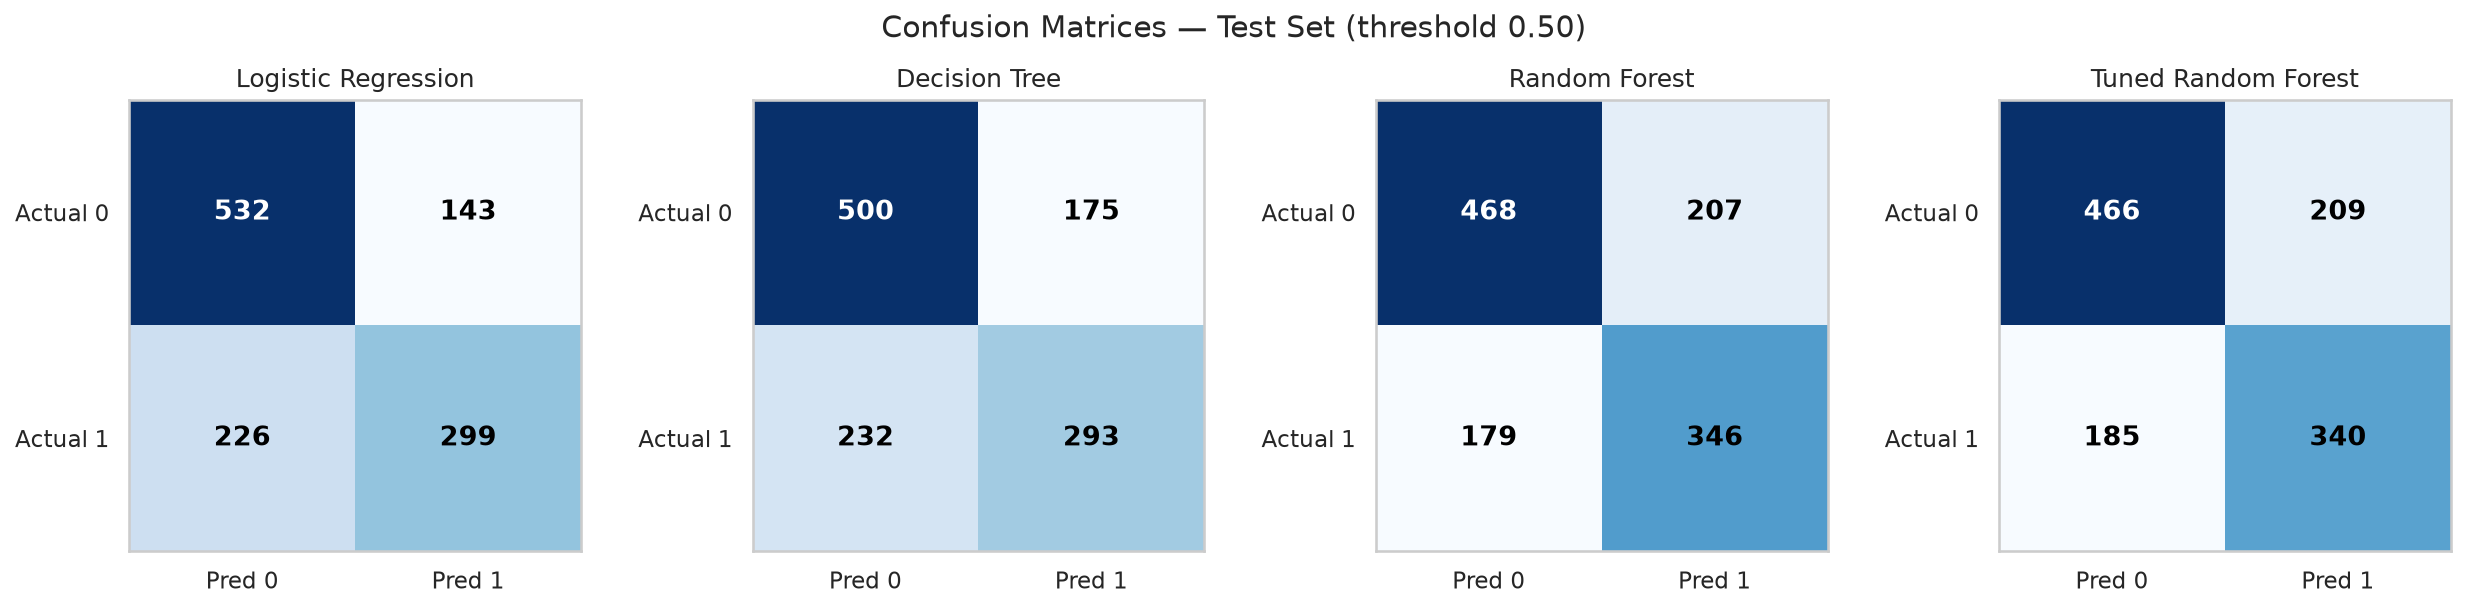

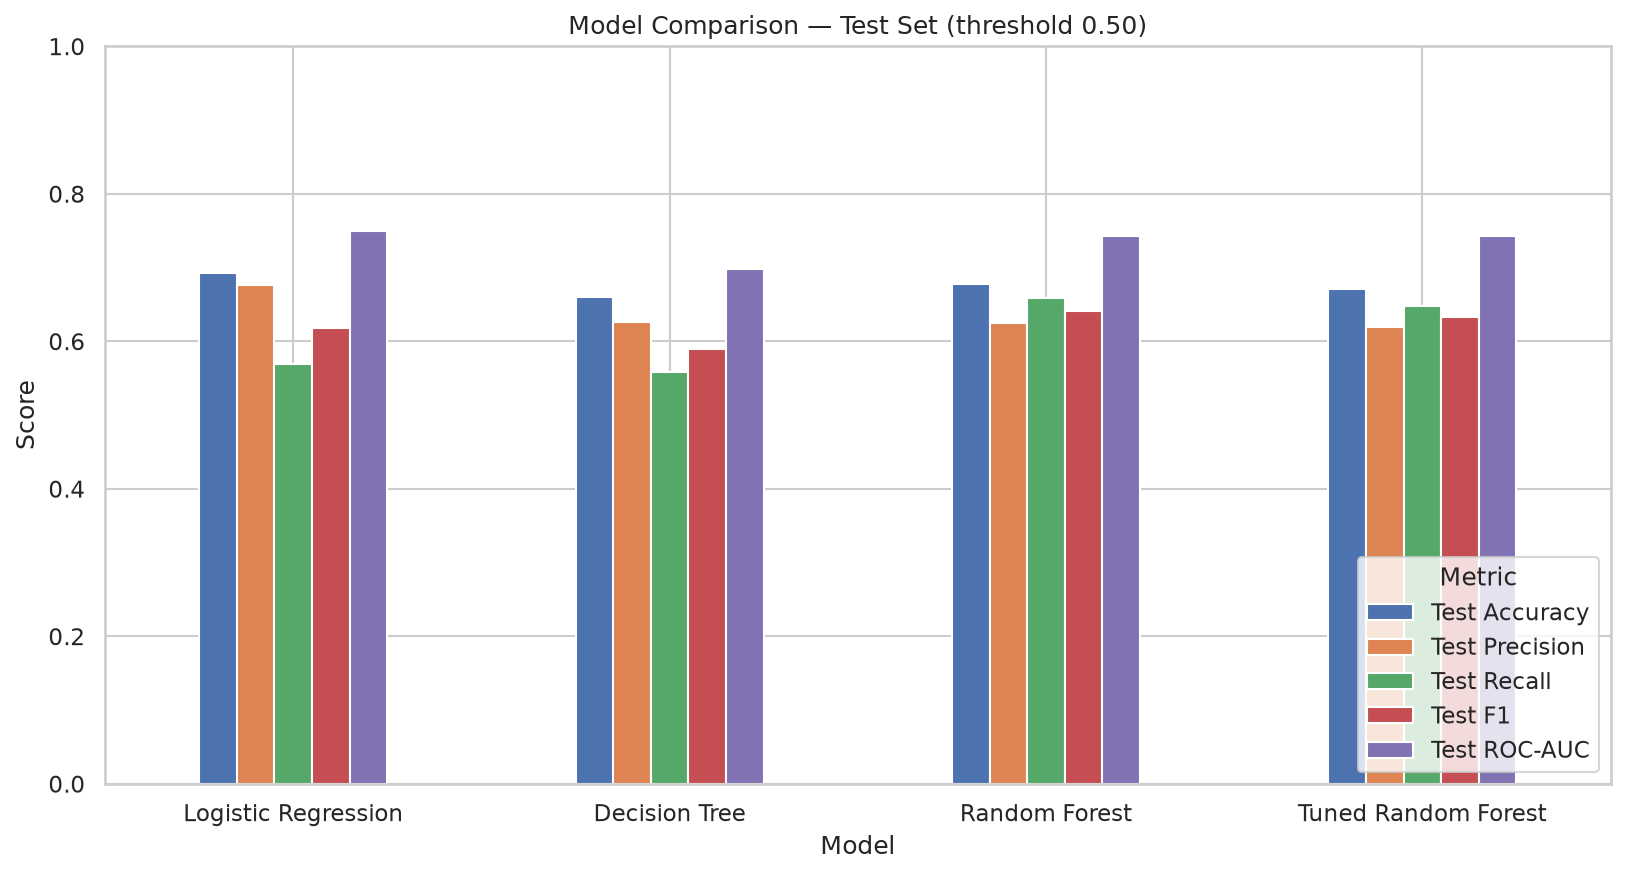

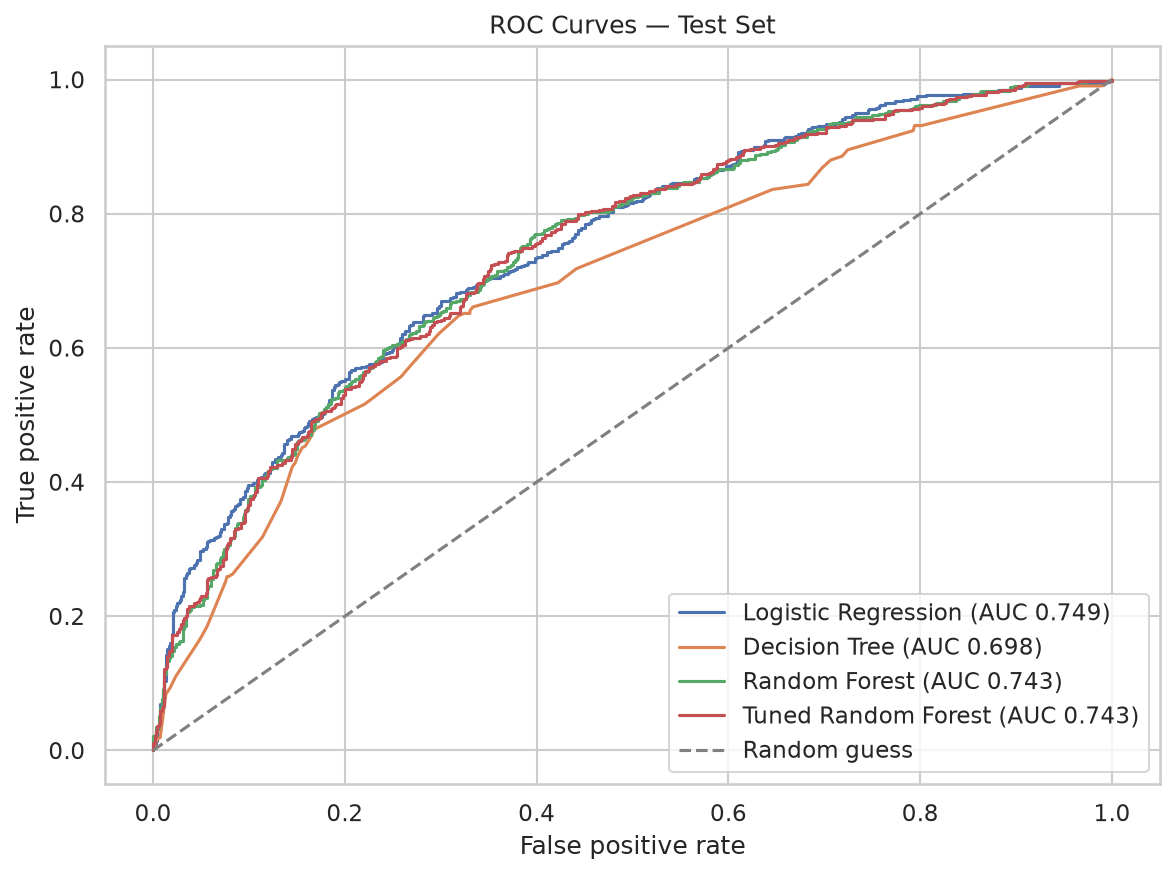

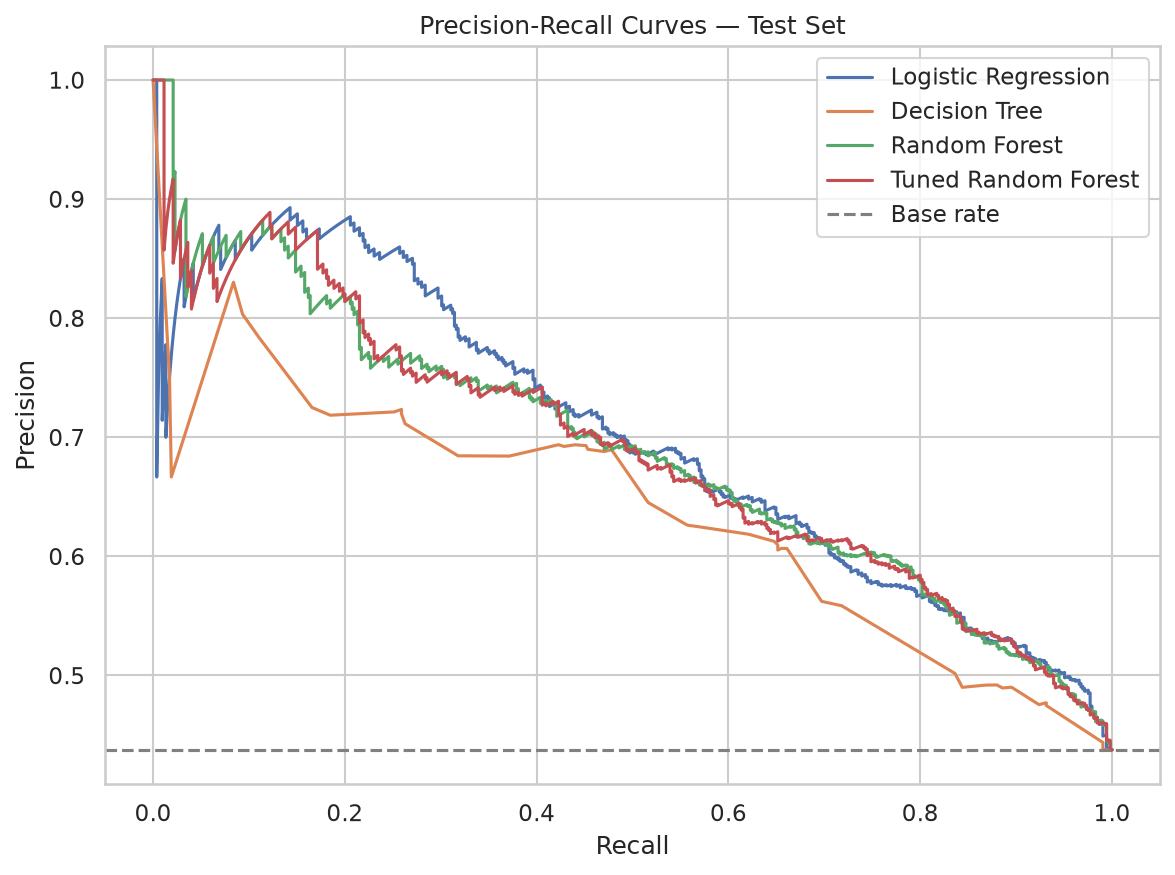

In [20]:
train.save_figures(
    experiment, y_train, y_test,
    importance=train.feature_importance(results[experiment["final_name"]]["pipeline"], X_test, y_test),
    coefficients=train.logistic_coefficients(results["logistic_regression"]["pipeline"]),
    rf_importance=train.rf_impurity_importance(results["tuned_random_forest"]["pipeline"]),
)

for name, r in results.items():
    print(f"{r['label']:<22} {r['test_default']['confusion_matrix']}   [[TN, FP], [FN, TP]]")

display(Image(filename=str(FIGURES_DIR / "confusion_matrices.png")))
display(Image(filename=str(FIGURES_DIR / "model_performance_comparison.png")))
display(Image(filename=str(FIGURES_DIR / "roc_curve_comparison.png")))
display(Image(filename=str(FIGURES_DIR / "precision_recall_curves.png")))

## 19. Final Model Selection

The final model is chosen by **cross-validated ROC-AUC on the training set** — not by test accuracy.

In [21]:
final_name = experiment["final_name"]
final = results[final_name]
print(f"Selected model: {final['label']}")
print(f"CV ROC-AUC    : {final['cv_roc_auc']:.4f}")
print(f"Train ROC-AUC : {final['train_roc_auc']:.4f}  (small gap -> little overfitting)")

Selected model: Logistic Regression
CV ROC-AUC    : 0.7415
Train ROC-AUC : 0.7494  (small gap -> little overfitting)


**Why Logistic Regression**

- *Predictive performance / generalisation*: highest CV ROC-AUC and test ROC-AUC; the smallest
  train–validation gap of all models. At their own thresholds the Random Forests reach a slightly
  higher test F1 (0.669 vs 0.664); that gap is too small to outweigh the points below.
- *Probability quality*: best Brier score, so "65%" is closer to a real 65% — important because the
  product shows a conversion probability.
- *Interpretability*: every coefficient has a direction and size that a sales manager can read.
- *Computational cost*: trains in milliseconds and scores 100,000+ leads in seconds.
- *Business fit*: the threshold is tuned for recall (next section), so few real buyers are missed.

The Random Forest was not selected because it overfits (large train–CV gap) and ranks
leads slightly worse than the simpler model. With real, more complex CRM data a non-linear model could win;
the pipeline makes that comparison easy to repeat.

## 20. Threshold Selection (Training Data Only)

The model outputs a probability. To turn it into a yes/no decision we need a threshold.
It is chosen on **5-fold out-of-fold predictions from the training set** by maximising F1.
The test set plays no part in this choice.

Business reasoning: a false negative (a missed buyer) costs a lost deal, while a false positive
costs one extra sales call, so a threshold favouring recall is acceptable.

Selected threshold: 0.32


,threshold,precision,recall,f1
15,0.25,0.5135,0.9115,0.6570
20,0.30,0.5450,0.8525,0.6649
22,0.32,0.5579,0.8278,0.6665
25,0.35,0.5774,0.7864,0.6659
30,0.40,0.6077,0.7127,0.6560
35,0.45,0.6406,0.6418,0.6412
40,0.50,0.6639,0.5618,0.6086


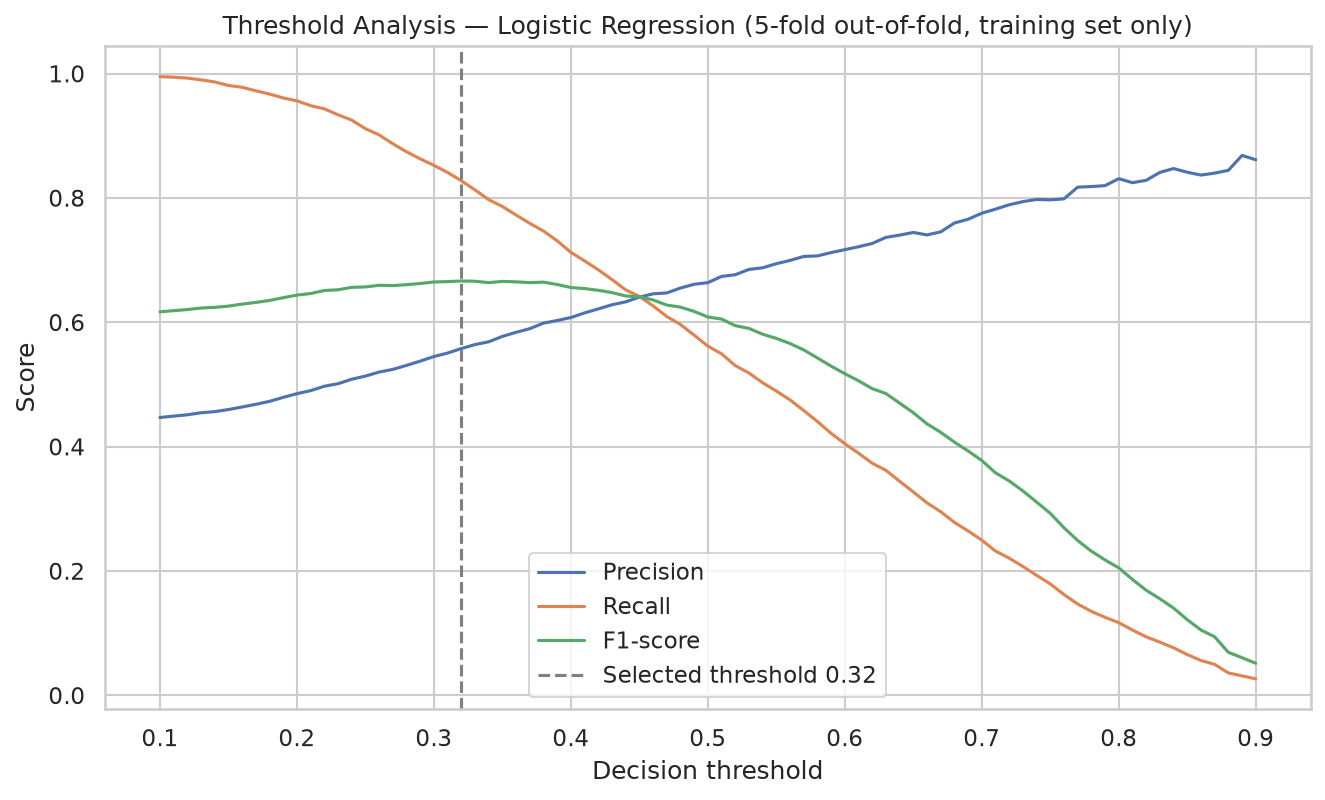

In [22]:
threshold = experiment["threshold"]
table = experiment["threshold_table"]
print(f"Selected threshold: {threshold:.2f}")
display(table[table["threshold"].isin([0.25, 0.30, threshold, 0.35, 0.40, 0.45, 0.50])].round(4))
display(Image(filename=str(FIGURES_DIR / "threshold_analysis.png")))

## 21. Final Test Evaluation

The test set is used once, at the threshold chosen above.

In [23]:
m = final["test_cv_threshold"]
for key in ("accuracy", "precision", "recall", "f1", "roc_auc", "brier_score"):
    print(f"{key:<12}: {m[key]:.4f}")
tn, fp, fn, tp = [v for row in m["confusion_matrix"] for v in row]
print(f"\nConfusion matrix [[TN, FP], [FN, TP]] = {m['confusion_matrix']}")
print(f"Buyers found: {tp} of {tp + fn}  |  missed: {fn}  |  extra calls on non-buyers: {fp}")

categories = pd.Series(final["test_probabilities"]).apply(
    lambda p: train.conversion_category(p, threshold)
)
summary = pd.DataFrame({"leads": categories.value_counts(),
                        "actual conversion rate": pd.Series(y_test.values).groupby(categories.values).mean().round(3)})
display(summary.loc[["High Potential", "Medium Potential", "Low Potential"]])

accuracy    : 0.6333
precision   : 0.5543
recall      : 0.8267
f1          : 0.6636
roc_auc     : 0.7492
brier_score : 0.1998

Confusion matrix [[TN, FP], [FN, TP]] = [[326, 349], [91, 434]]
Buyers found: 434 of 525  |  missed: 91  |  extra calls on non-buyers: 349


,leads,actual conversion rate
High Potential,177,0.831
Medium Potential,606,0.474
Low Potential,417,0.218


The categories are ordered as intended: higher categories convert more often. The Low/Medium
boundary is the analysed threshold; the Medium/High boundary (0.70) is a **business convention**,
not a statistically derived value.

## 22. Feature Importance

Two views:

1. **Permutation importance** (model-agnostic): drop in test ROC-AUC when one raw feature is shuffled.
2. **Logistic Regression coefficients** on standardised / one-hot features (direction + size).

The Random Forest's built-in (impurity) importance is shown for contrast: it is biased towards
continuous, high-cardinality features.

,feature,importance_mean,importance_std
0,demo_attended,0.0411,0.0074
1,quotation_sent,0.0291,0.0049
2,response_time_hours,0.0252,0.0057
3,lead_source,0.0207,0.0055
4,previous_customer,0.0196,0.0043
5,company_size,0.0090,0.0042
6,followups,0.0083,0.0028
7,quotation_value,0.0073,0.0014
8,industry,0.0045,0.0025
9,salesperson_experience,0.0010,0.0009


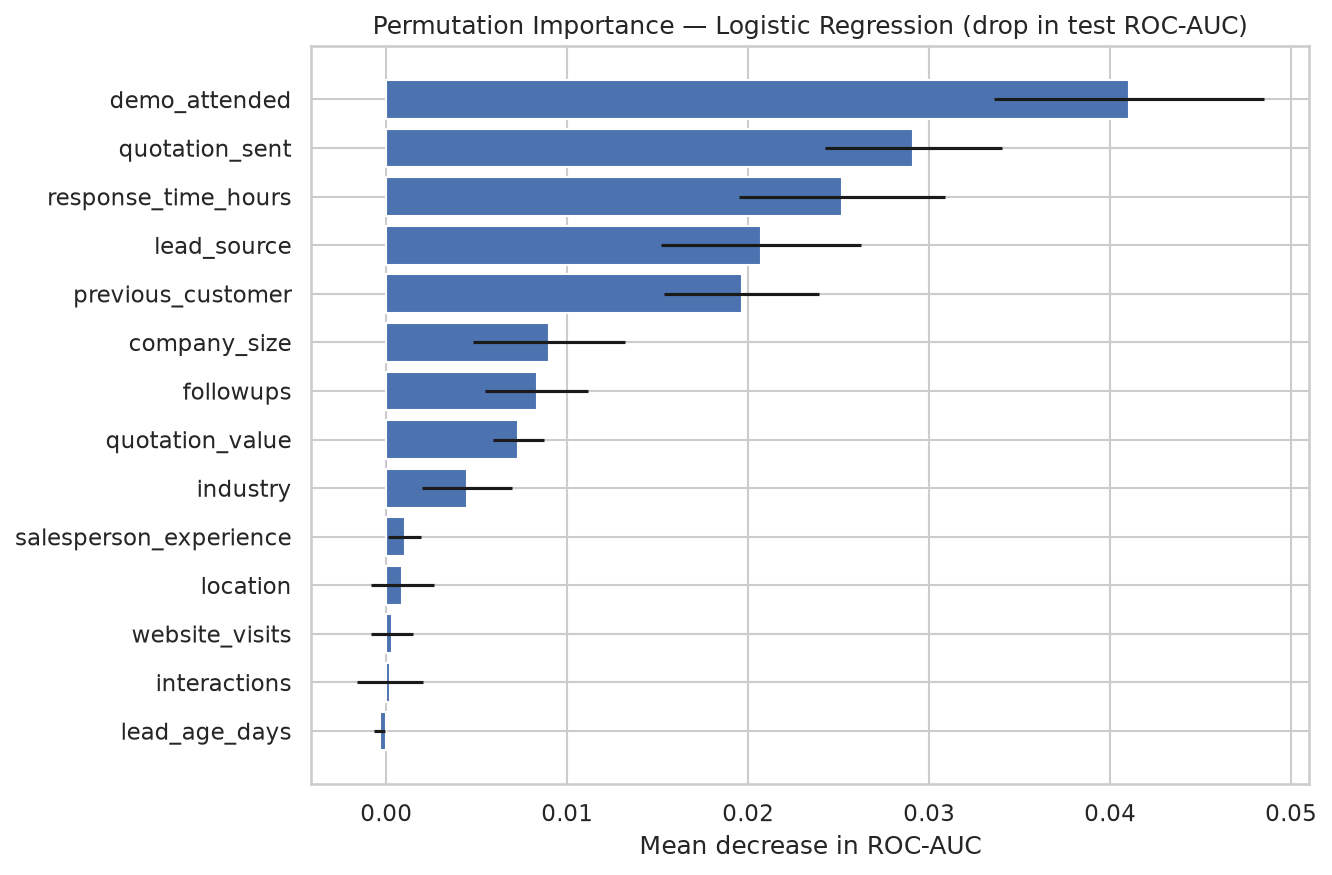

,feature,coefficient
0,categorical__lead_source_Cold Call,-0.6394
1,categorical__lead_source_Referral,0.4412
2,categorical__company_size_Small,-0.3545
3,numerical__demo_attended,0.3522
4,categorical__lead_source_Social Media,-0.3498
5,categorical__company_size_Enterprise,0.3433
6,numerical__response_time_hours,-0.3295
7,categorical__lead_source_Partner,0.2908
8,numerical__quotation_sent,0.2796
9,numerical__followups,0.2503


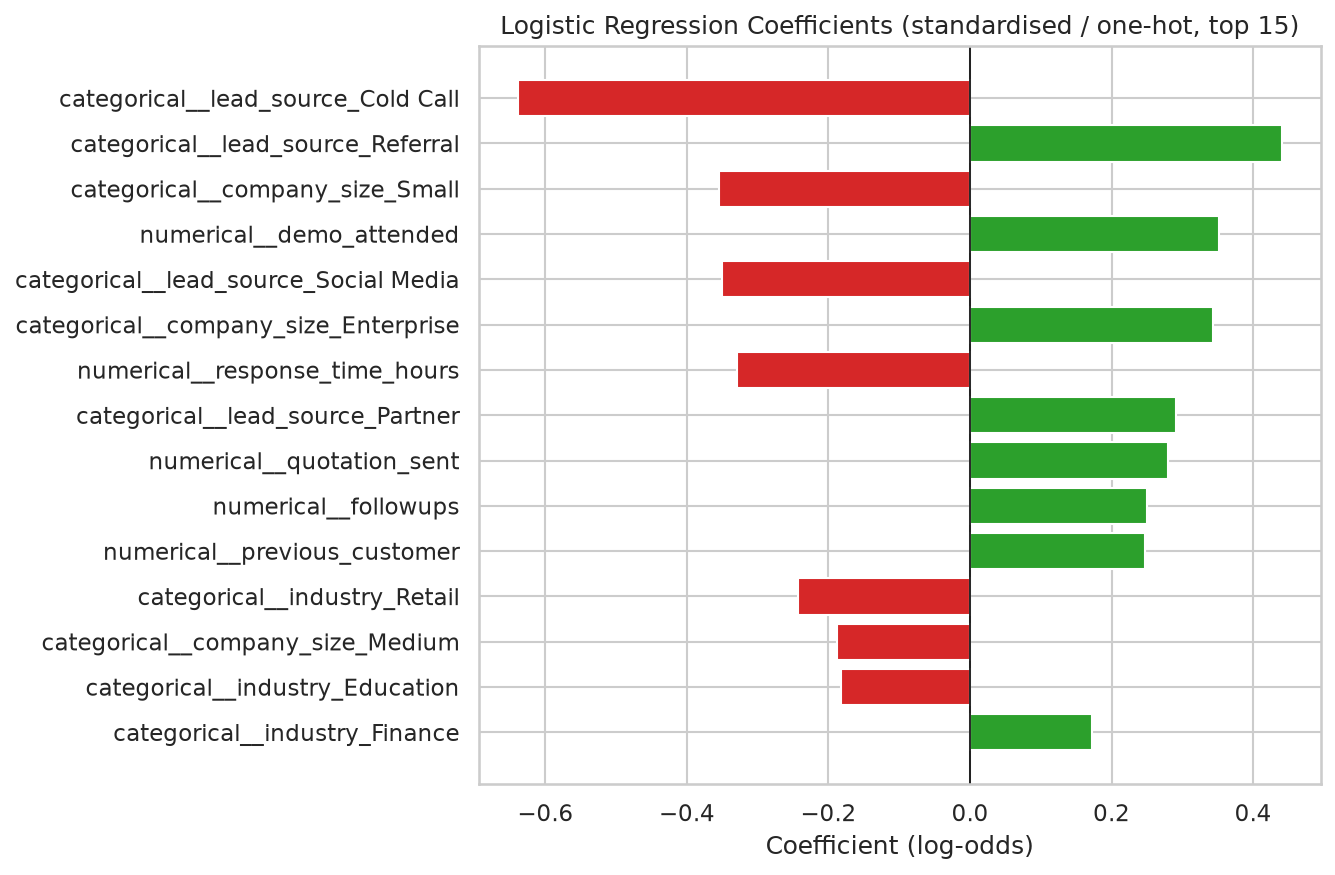

,feature,importance
0,numerical__quotation_value,0.1184
1,numerical__response_time_hours,0.1163
2,numerical__demo_attended,0.1121
3,numerical__interactions,0.0863
4,numerical__lead_age_days,0.0726
5,numerical__quotation_sent,0.0718
6,numerical__followups,0.0679
7,numerical__salesperson_experience,0.0565
8,numerical__website_visits,0.0442
9,numerical__previous_customer,0.0350


In [24]:
importance = train.feature_importance(final["pipeline"], X_test, y_test)
display(importance.round(4))
display(Image(filename=str(FIGURES_DIR / "permutation_importance.png")))

coefficients = train.logistic_coefficients(results["logistic_regression"]["pipeline"])
display(coefficients.head(15).round(4))
display(Image(filename=str(FIGURES_DIR / "logistic_regression_coefficients.png")))

display(train.rf_impurity_importance(results["tuned_random_forest"]["pipeline"]).head(10).round(4))

**Interpretation and limitations**

- Demo attended, quotation sent, response time, lead source and previous customer matter most.
- `lead_age_days` and `location` contribute nothing (they have no effect in the generator).
  `interactions` and `website_visits` contribute almost nothing on their own because their effect
  runs through follow-ups, demos and quotations — correlated features share credit. The Random Forest's
  impurity importance ranks `lead_age_days` near the top — an example of that method's bias
  towards continuous features.
- `quotation_sent` and `quotation_value` are highly correlated (Spearman ≈ 0.95); correlated features
  share importance, so each one's individual score understates the pair.
- Importance is **predictive, not causal**: it shows what the model relies on, not what would change
  a customer's decision.
- The dataset is synthetic, so these findings describe the generator's assumptions, not a real market.

## 23. Prediction Check With the Saved Pipeline

The prediction engine loads `models/lead_conversion_pipeline.joblib` — no retraining.

In [25]:
from src.predictor import predict_lead, model_health, pipeline as saved_pipeline
import numpy as np

print(model_health())

saved_probabilities = saved_pipeline.predict_proba(X_test)[:, 1]
print("Saved pipeline reproduces notebook probabilities:",
      np.allclose(saved_probabilities, final["test_probabilities"]))

example = {
    "lead_source": "Referral", "industry": "Technology", "location": "Pune",
    "company_size": "Large", "lead_age_days": 15, "interactions": 9, "followups": 4,
    "response_time_hours": 1.5, "quotation_sent": 1, "quotation_value": 150000,
    "website_visits": 8, "previous_customer": 1, "demo_attended": 1,
    "salesperson_experience": 10,
}
predict_lead(example)

{'model_loaded': True, 'model_name': 'Logistic Regression', 'model_type': 'LogisticRegression', 'feature_count': 14, 'deployment_threshold': 0.32, 'threshold_method': 'Maximum F1 on 5-fold out-of-fold predictions from the training set only'}
Saved pipeline reproduces notebook probabilities: True


{'conversion_probability': 0.9543,
 'conversion_percentage': 95.43,
 'predicted_class': 1,
 'prediction': 'Likely to Convert',
 'threshold': 0.32,
 'category': 'High Potential'}

## Conclusion

- A leakage-safe pipeline (split → preprocess inside the pipeline → CV on training data) was built.
- Logistic Regression was selected on cross-validated ROC-AUC; it also generalises and calibrates best.
- The decision threshold was chosen from training out-of-fold predictions and favours recall.
- Final test results, limitations and future work are documented in `reports/evaluation_report.md`.